# 04 · Problema 2: ¿habrá comercio el próximo mes? (clasificación)

**Fase CRISP-DM:** modelado y evaluación técnica para la segunda parte de la pregunta 3 del
proyecto: qué flujos esporádicos se repetirán.

## Definición del problema

| Elemento | Decisión | Justificación |
|---|---|---|
| **Población** | Series **intermitentes**: comercio en 1 a 9 de los últimos 12 meses (evaluado en cada origen) | Complementa el Problema 1; aquí "¿cuánto?" no tiene sentido (la mitad de los meses valen 0) |
| **Objetivo** | 1 si la serie tiene comercio en t + 1 | La pregunta útil para estas series es si el flujo ocurrirá |
| **Features** | Las de forecasting + patrón de actividad + **grafo** (densidad de relatedness, ubicuidad, diversidad) | El grafo se **reconstruye en cada origen** con los 12 meses previos (sin información futura) |
| **Grafo de importaciones** | Productos que **compran las mismas empresas** (cadenas de insumos) | Misma lógica que en exportaciones; el ID de importador también es válido dentro del mes |
| **Validación** | Walk-forward mensual · validación jul–dic 2025 · **test ene–ago 2026** | Igual que el Problema 1 |
| **Métricas** | AP (PR-AUC), ROC-AUC, **Brier**, log-loss, **calibración** | Ranking + calidad de la probabilidad |

**Por qué importa la calibración:** si el modelo dice "70% de probabilidad", debería ocurrir ~70% de las
veces. Un modelo puede ordenar bien (AUC alta) y aun así entregar probabilidades sesgadas, lo que es
inútil si las probabilidades se usan para planificar (inventarios, logística, metas comerciales).

**Brier score** = media de (p − y)². Es el error cuadrático de la probabilidad; menor es mejor. Premia a
la vez la discriminación y la calibración.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

from comercio_chile import viz, classify as C
from comercio_chile.features import load_grid
from comercio_chile.config import PROCESSED

viz.setup()
pd.set_option("display.width", 220)
FLOWS = ["exportaciones", "importaciones"]
G = {f: load_grid(f) for f in FLOWS}
VAL = [str(p) for p in pd.period_range("2025-07", "2025-12", freq="M")]
TEST = [str(p) for p in pd.period_range("2026-01", "2026-08", freq="M")]

rows = []
for f, g in G.items():
    for per in ["2025-06", "2025-12", "2026-07"]:
        t = g.t_of(per); m = C.intermittent_mask(g, t)
        rows.append({"flujo": f, "origen": per, "series intermitentes": int(m.sum()),
                     "% con comercio en t+1": 100 * (g.valor[m, t + 1] > 0).mean(),
                     "% del valor de t+1": 100 * g.valor[m, t + 1].sum() / g.valor[:, t + 1].sum()})
pd.DataFrame(rows).set_index(["flujo", "origen"]).round(1)

series intermitentes  % con comercio en t+1  % del valor de t+1
flujo         origen                                                                  
exportaciones 2025-06                 21987                   21.9                 9.9
              2025-12                 22273                   20.4                12.5
              2026-07                 22379                   19.7                10.0
importaciones 2025-06                 51109                   24.8                10.1
              2025-12                 51267                   21.4                11.1
              2026-07                 50729                   23.5                 9.4

Hay muchas series (~22 mil de exportación y ~51 mil de importación por mes). Solo ~20–24% tiene comercio
el mes siguiente, y en conjunto representan ~10% del valor. Son los flujos esporádicos, nuevos o en
retirada de la canasta comercial.

## 1. Baselines

| Baseline | Probabilidad predicha |
|---|---|
| **Persistencia** | 1 si hubo comercio en t, 0 si no |
| **Persistencia estacional** | 1 si hubo comercio en el mismo mes del año anterior |
| **Frecuencia 12m** | fracción de los últimos 12 meses con comercio (ya es una probabilidad) |

## 2. Validación (jul–dic 2025): modelo, ablación del grafo y baselines

In [2]:
def tabla(pred, extra=None):
    out = {"LightGBM + grafo": C.metrics(pred.y.values, pred.modelo.values)}
    if extra is not None:
        out["LightGBM sin grafo"] = C.metrics(pred.y.values, extra)
    for b in C.BASELINES:
        out[b] = C.metrics(pred.y.values, pred[b].values)
    return pd.DataFrame(out).T

val = {}
for f, g in G.items():
    pg, pn = C.walk_forward(g, VAL, True), C.walk_forward(g, VAL, False)
    val[f] = tabla(pg, pn.modelo.values)
pd.concat(val).round(4)

AP     AUC   Brier  LogLoss  tasa_base         n
exportaciones LightGBM + grafo         0.5628  0.8078  0.1253   0.3997     0.2071  132954.0
              LightGBM sin grafo       0.5605  0.8032  0.1259   0.4024     0.2071  132954.0
              persistencia             0.2858  0.6292  0.2632   3.6361     0.2071  132954.0
              persistencia_estacional  0.2674  0.6060  0.2722   3.7601     0.2071  132954.0
              frecuencia_12m           0.4828  0.7815  0.1315   0.4185     0.2071  132954.0
importaciones LightGBM + grafo         0.5693  0.7999  0.1413   0.4401     0.2407  307155.0
              LightGBM sin grafo       0.5664  0.7957  0.1420   0.4430     0.2407  307155.0
              persistencia             0.3136  0.6183  0.2903   4.0104     0.2407  307155.0
              persistencia_estacional  0.3043  0.6072  0.2982   4.1199     0.2407  307155.0
              frecuencia_12m           0.5185  0.7826  0.1446   0.4511     0.2407  307155.0

**Lectura:**
- El modelo supera claramente al mejor baseline (frecuencia 12m) en AP, AUC y Brier.
- La **persistencia** es muy mala: estas series son intermitentes precisamente porque cambian de estado. Su
  log-loss altísima viene de predecir probabilidades de 0 o 1 y equivocarse con total confianza.
- **El grafo aporta muy poco en promedio** (+0,002–0,003 de AP). Antes de descartarlo se plantea una
  hipótesis: en el notebook 02, el grafo mejoró +17% la predicción de pares **sin historia** (*cold start*).
  Aquí las series sí tienen historia, que probablemente domina. **Si la hipótesis es correcta, el grafo
  debería aportar más en las series con menos historia.** Se verifica en el test.

## 3. Test (ene–ago 2026), evaluación única

In [3]:
test = []
for f, g in G.items():
    pg, pn = C.walk_forward(g, TEST, True), C.walk_forward(g, TEST, False)
    pg["sin_grafo"], pg["flujo"] = pn.modelo.values, f
    t0 = pg.periodo.map(lambda T: g.t_of(T) - 1).to_numpy()
    pg["meses_activos"] = [(g.valor[s, max(0, t - 11): t + 1] > 0).sum() for s, t in zip(pg.serie.to_numpy(), t0)]
    test.append(pg)
T = pd.concat(test, ignore_index=True)
T.to_parquet(PROCESSED / "clasificacion_test.parquet")
pd.concat({f: tabla(d, d.sin_grafo.values) for f, d in T.groupby("flujo")}).round(4)

AP     AUC   Brier  LogLoss  tasa_base         n
exportaciones LightGBM + grafo         0.5599  0.8088  0.1221   0.3908     0.1998  179202.0
              LightGBM sin grafo       0.5580  0.8043  0.1225   0.3932     0.1998  179202.0
              persistencia             0.2769  0.6279  0.2569   3.5488     0.1998  179202.0
              persistencia_estacional  0.2613  0.6078  0.2634   3.6394     0.1998  179202.0
              frecuencia_12m           0.4703  0.7807  0.1293   0.4129     0.1998  179202.0
importaciones LightGBM + grafo         0.5544  0.8013  0.1364   0.4271     0.2271  408414.0
              LightGBM sin grafo       0.5517  0.7973  0.1370   0.4298     0.2271  408414.0
              persistencia             0.2969  0.6159  0.2825   3.9036     0.2271  408414.0
              persistencia_estacional  0.2903  0.6085  0.2897   4.0025     0.2271  408414.0
              frecuencia_12m           0.5004  0.7830  0.1407   0.4410     0.2271  408414.0

In [4]:
def boot_ap(d, a, b, n=200, seed=42):
    from sklearn.metrics import average_precision_score as ap
    rng = np.random.default_rng(seed); ser = d.serie.unique(); idx = d.groupby("serie").indices
    y, pa, pb = d.y.to_numpy(), d[a].to_numpy(), d[b].to_numpy()
    diffs = []
    for _ in range(n):
        s = np.concatenate([idx[k] for k in rng.choice(ser, len(ser))])
        diffs.append(ap(y[s], pa[s]) - ap(y[s], pb[s]))
    return np.mean(diffs), np.quantile(diffs, .025), np.quantile(diffs, .975)

rows = []
for f, d in T.groupby("flujo"):
    for nombre, (a, b) in {"modelo vs frecuencia 12m": ("modelo", "frecuencia_12m"), "con vs sin grafo": ("modelo", "sin_grafo")}.items():
        m, lo, hi = boot_ap(d, a, b)
        rows.append({"flujo": f, "comparación": nombre, "ΔAP": m, "IC95% inf": lo, "IC95% sup": hi})
    hist = pd.cut(d.meses_activos, [0, 1, 3, 9], labels=["1 mes", "2–3 meses", "4–9 meses"])
    for k, s in d.groupby(hist, observed=True):
        m, lo, hi = boot_ap(s, "modelo", "sin_grafo")
        rows.append({"flujo": f, "comparación": f"con vs sin grafo · historia {k}", "ΔAP": m, "IC95% inf": lo, "IC95% sup": hi})
boot = pd.DataFrame(rows).set_index(["flujo", "comparación"])
boot.round(4)

ΔAP  IC95% inf  IC95% sup
flujo         comparación                                                        
exportaciones modelo vs frecuencia 12m               0.0897     0.0860     0.0935
              con vs sin grafo                       0.0019     0.0011     0.0026
              con vs sin grafo · historia 1 mes      0.0095     0.0071     0.0121
              con vs sin grafo · historia 2–3 meses  0.0056     0.0031     0.0083
              con vs sin grafo · historia 4–9 meses  0.0003    -0.0010     0.0015
importaciones modelo vs frecuencia 12m               0.0539     0.0523     0.0554
              con vs sin grafo                       0.0027     0.0023     0.0032
              con vs sin grafo · historia 1 mes      0.0133     0.0113     0.0152
              con vs sin grafo · historia 2–3 meses  0.0093     0.0072     0.0110
              con vs sin grafo · historia 4–9 meses  0.0017     0.0011     0.0024

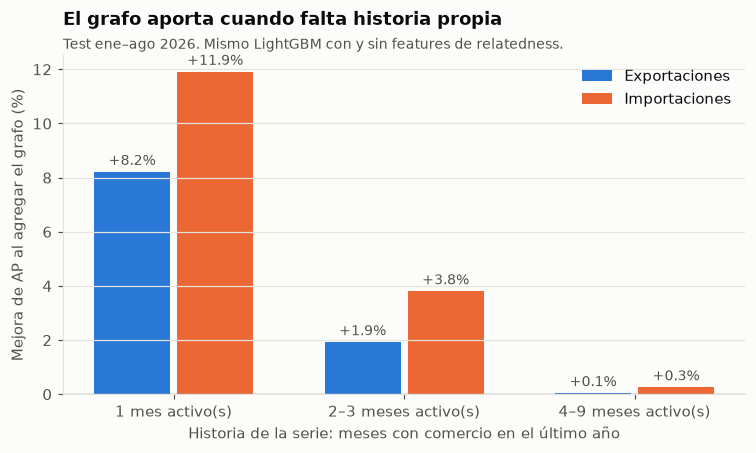

In [5]:
from sklearn.metrics import average_precision_score as ap
rows = []
for f, d in T.groupby("flujo"):
    for k, s in d.groupby(pd.cut(d.meses_activos, [0, 1, 3, 9], labels=["1 mes", "2–3 meses", "4–9 meses"]), observed=True):
        rows.append({"flujo": f, "historia": str(k), "mejora relativa de AP (%)": 100 * (ap(s.y, s.modelo) / ap(s.y, s.sin_grafo) - 1)})
gh = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
cats = ["1 mes", "2–3 meses", "4–9 meses"]; x = np.arange(3); w = 0.36
for i, (f, c) in enumerate([("exportaciones", viz.EXPORT), ("importaciones", viz.IMPORT)]):
    v = gh[gh.flujo == f].set_index("historia").reindex(cats)["mejora relativa de AP (%)"]
    ax.bar(x + (i - 0.5) * w, v, width=w - 0.03, color=c, label=f.capitalize())
    for xx, vv in zip(x + (i - 0.5) * w, v):
        ax.text(xx, vv + 0.25, f"{vv:+.1f}%", ha="center", fontsize=9, color=viz.TEXT_2)
ax.axhline(0, color=viz.TEXT_2, lw=0.8)
ax.set_xticks(x, [f"{c} activo(s)" for c in cats]); ax.set_xlabel("Historia de la serie: meses con comercio en el último año")
ax.set_ylabel("Mejora de AP al agregar el grafo (%)"); ax.legend()
ax.set_title("El grafo aporta cuando falta historia propia")
viz.subtitle(ax, "Test ene–ago 2026. Mismo LightGBM con y sin features de relatedness.")
viz.save(fig, "17_grafo_segun_historia"); fig

**La hipótesis se confirma.** El aporte del grafo es **inversamente proporcional a la historia propia de
la serie**: +8% (exportaciones) y +12% (importaciones) en las series con un solo mes activo en el año, y
≈ 0 en las que tienen 4–9 meses. Esto **unifica** los resultados del proyecto: el grafo de capacidades es una
herramienta para **predecir con poca información** (pares nuevos en el notebook 02, series casi sin historia
aquí). Cuando la serie tiene historia, su propio patrón domina.

Además, **la técnica se transfiere**: el grafo de importaciones (productos que compran las mismas empresas)
funciona igual que el de exportaciones.

## 4. Curvas precisión–recall y calibración

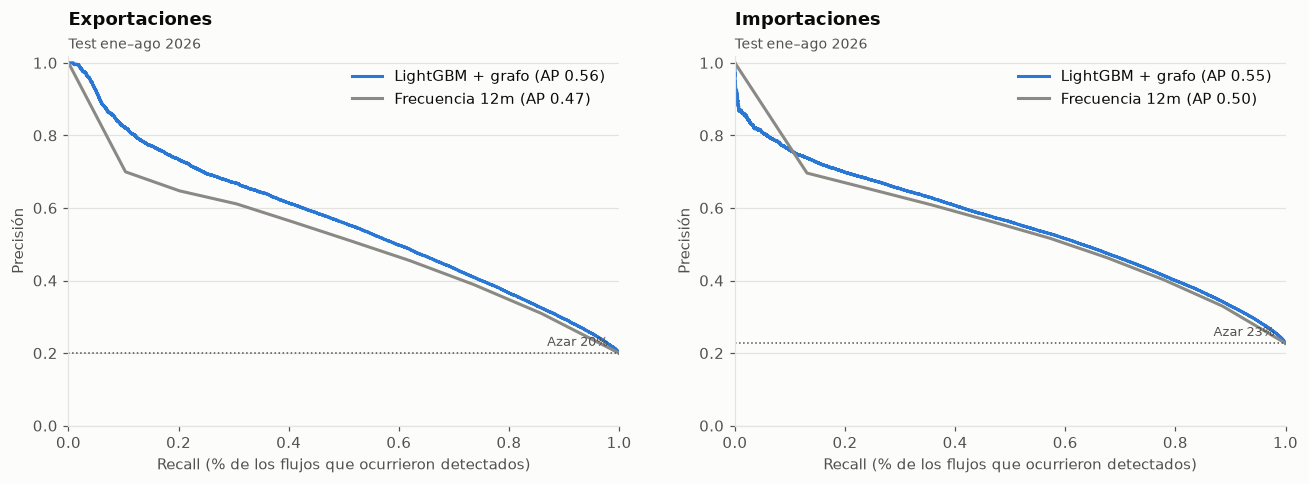

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (f, d) in zip(axes, T.groupby("flujo")):
    for col, c, name in [("modelo", viz.SERIES[0], "LightGBM + grafo"), ("frecuencia_12m", viz.NEUTRAL, "Frecuencia 12m")]:
        pr, rc, _ = precision_recall_curve(d.y, d[col])
        ax.plot(rc, pr, color=c, label=f"{name} (AP {ap(d.y, d[col]):.2f})")
    ax.axhline(d.y.mean(), color=viz.TEXT_2, ls=":", lw=1)
    ax.text(0.98, d.y.mean() + 0.02, f"Azar {d.y.mean():.0%}", ha="right", fontsize=8.5, color=viz.TEXT_2)
    ax.set_xlabel("Recall (% de los flujos que ocurrieron detectados)"); ax.set_ylabel("Precisión")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend(loc="upper right"); ax.set_title(f.capitalize())
    viz.subtitle(ax, "Test ene–ago 2026")
fig.tight_layout(w_pad=3)
viz.save(fig, "18_precision_recall"); fig

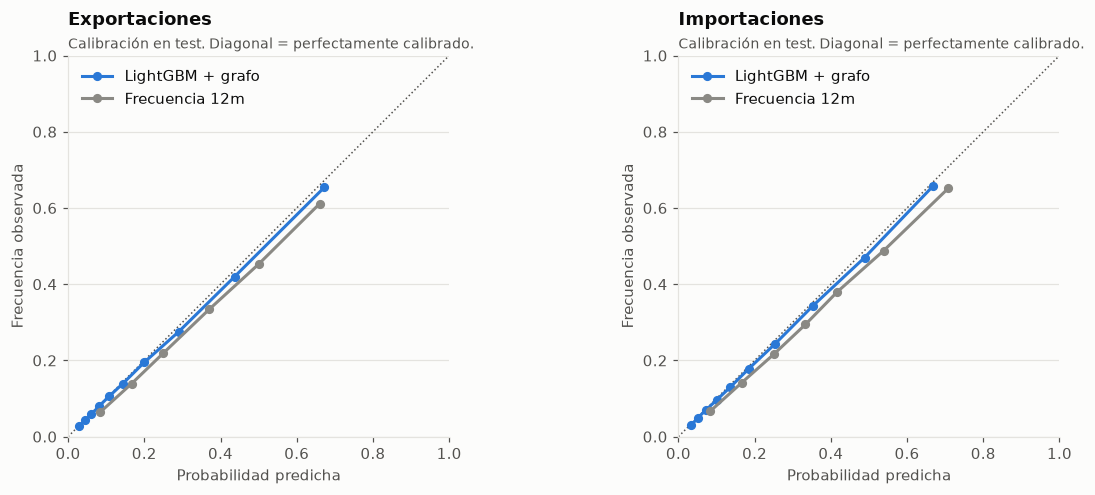

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (f, d) in zip(axes, T.groupby("flujo")):
    ax.plot([0, 1], [0, 1], color=viz.TEXT_2, ls=":", lw=1)
    for col, c, name in [("modelo", viz.SERIES[0], "LightGBM + grafo"), ("frecuencia_12m", viz.NEUTRAL, "Frecuencia 12m")]:
        fr, mp = calibration_curve(d.y, d[col], n_bins=10, strategy="quantile")
        ax.plot(mp, fr, color=c, marker="o", markersize=5, label=name)
    ax.set_xlabel("Probabilidad predicha"); ax.set_ylabel("Frecuencia observada")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal"); ax.legend(loc="upper left")
    ax.set_title(f.capitalize()); viz.subtitle(ax, "Calibración en test. Diagonal = perfectamente calibrado.")
fig.tight_layout(w_pad=3)
viz.save(fig, "19_calibracion"); fig

**Lectura:**
- **Precisión–recall:** el modelo domina al baseline en **casi** todo el rango. La excepción es el extremo
  de muy bajo recall en importaciones (< ~12%): ahí están las series activas 9 de 12 meses, para las que la
  frecuencia histórica ya es un predictor casi perfecto. *Nota técnica:* la curva del baseline tiene pocos
  puntos porque la frecuencia solo toma 9 valores distintos (1/12 … 9/12), y la interpolación lineal entre
  ellos la favorece levemente en los extremos.
- **Calibración:** las probabilidades del modelo siguen de cerca la diagonal, sin necesidad de recalibrar
  (LightGBM con pérdida log-loss tiende a quedar bien calibrado con suficientes datos). La frecuencia 12m se
  desvía más, porque no distingue, por ejemplo, entre "activo 3 de los últimos 3 meses" y "activo 3 meses
  hace un año".

## 5. ¿Qué umbral usar? El trade-off precisión vs recall es una decisión de negocio

Un clasificador entrega probabilidades. Convertirlas en decisiones ("esperamos este flujo: preparamos la
logística") exige un **umbral**, y el umbral correcto depende del **costo de cada error**:
- **Falso positivo** (se esperaba comercio y no ocurrió): costo de preparar sin necesidad.
- **Falso negativo** (ocurrió y no se anticipó): costo de no estar preparado.

In [8]:
rows = []
for f, d in T.groupby("flujo"):
    for thr in [0.2, 0.3, 0.5, 0.7]:
        pred = d.modelo >= thr
        tp = (pred & (d.y == 1)).sum()
        rows.append({"flujo": f, "umbral": thr, "% de series marcadas": 100 * pred.mean(),
                     "precisión": tp / max(pred.sum(), 1), "recall": tp / d.y.sum()})
pd.DataFrame(rows).set_index(["flujo", "umbral"]).round(3)

% de series marcadas  precisión  recall
flujo         umbral                                         
exportaciones 0.2                   34.747      0.417   0.725
              0.3                   23.936      0.499   0.597
              0.5                   11.649      0.632   0.369
              0.7                    3.192      0.791   0.126
importaciones 0.2                   42.426      0.415   0.776
              0.3                   29.755      0.492   0.645
              0.5                   14.147      0.615   0.383
              0.7                    2.976      0.759   0.100

**Ejemplo de razonamiento:** si un falso negativo cuesta 3 veces más que un falso positivo, conviene marcar
un flujo cuando p × 3 > (1 − p) × 1, es decir, **p > 0,25**. El umbral óptimo es
**costo_FP / (costo_FP + costo_FN)**, y eso solo funciona si las probabilidades están **bien calibradas**:
otra razón por la que la calibración importa.

## 6. Conclusiones del Problema 2

1. El modelo supera al mejor baseline (frecuencia 12m) en test: **AP +19% en exportaciones y +11% en
   importaciones**, con mejor Brier y buena calibración.
2. **El grafo aporta donde falta historia** (+8% / +12% de AP en series con un solo mes activo) y casi nada
   donde la serie tiene historia propia. Es coherente con el experimento de *cold start* del notebook 02.
3. El grafo construido con **importadores** funciona igual que el de exportadores: la técnica se transfiere.
4. El umbral de decisión no es un detalle técnico: se deriva de los costos de negocio de cada error.